# 04 — Shower-particle 4-vectors (first look)

This notebook inspects the **full Geant4 shower cascade** of a single electromagnetic
event: one 50 GeV photon fired into the silicon-tungsten ECal barrel along +y.

The main pipeline keeps only the *primary* particle and reconstructs a single energy.
Here we instead persist the 4-vector of **every** secondary produced in the shower — the
eventual input to a high-fidelity silicon pixel simulation (**PIXELAV**).

**Units throughout:** momenta / energies / masses in GeV, positions / vertices in mm.

## 1. How this sample was generated — required changes

Generating a full-cascade sample is **not** the ddsim default: out of the box, an ECal
shower's secondaries are discarded (see §2). Starting from an ordinary particle-gun
steering, **two** settings make the difference. They live in
[`sim/run_sim_fullcascade.py`](../sim/run_sim_fullcascade.py):

| # | Setting | Why it's needed |
|---|---------|-----------------|
| 1 | `SIM.part.userParticleHandler = ""` | **The key change.** ddsim's default `Geant4TCUserParticleHandler` restricts MC-truth to the inner *tracking* region. ECal shower secondaries are born at r > 1267 mm — outside that region — so they get merged into their parent and never stored. Disabling the user handler removes that region cut. |
| 2 | `SIM.part.keepAllParticles = True` | Keep every Geant4 track as an `MCParticle` (no kinetic-energy pruning / merge-into-parent). |

The output is standard **EDM4hep** ROOT — the same format notebooks 01–03 use. Two practical notes:
- **Keep the steering pure ASCII.** A stray non-ASCII character (em-dash, curly quote) in a
  comment lands in the run metadata and breaks the EDM4hep RunHeader `map<string,string>`
  conversion (see [`docs/troubleshooting.md`](../docs/troubleshooting.md)).
- **Use Key4hep `2026-04-08` (or newer) for the full cascade.** The pinned `2026-02-01`
  podio writer crashes (`free(): invalid pointer`) while *finalizing* a file with this many
  truth particles; `2026-04-08` fixes it. (Standard 1-particle samples are fine on either.)

**To regenerate the sample** (on EAF):

```bash
source /cvmfs/sw.hsf.org/key4hep/setup.sh -r 2026-04-08
export LD_LIBRARY_PATH="$HOME/lib_hack:$LD_LIBRARY_PATH"
cd geometry
ddsim --compactFile SiD_TestBeam.xml \
      --steeringFile ../sim/run_sim_fullcascade.py \
      --numberOfEvents 1
python ../analysis/extract_cascade.py        # EDM4hep ROOT -> models/*.npz (uproot)
```

## 2. What's stored — and what's *extra* in this sample

`ddsim` writes an EDM4hep ROOT `TTree` named **`events`**. The collections we use:

| Collection | EDM4hep type | What it is |
|------------|--------------|------------|
| `MCParticles`    | `MCParticle`        | the truth particles |
| `ECalBarrelHits` | `SimCalorimeterHit` | energy deposits in the silicon |
| (hit contributions) | `CaloHitContribution` | per-step deposit truth, linked back to an `MCParticle` |

**Per `MCParticle`** (note it keeps the momentum and position at *both* ends of the track):

| Branch | Meaning |
|--------|---------|
| `PDG`, `mass`, `charge` | particle identity (PDG code, GeV, e) |
| `momentum.{x,y,z}` / `momentumAtEndpoint.{x,y,z}` | momentum at **production** / at **end** (GeV) |
| `vertex.{x,y,z}` / `endpoint.{x,y,z}` | **production** vertex / **end** point (mm) |
| `generatorStatus`, `simulatorStatus`, `time` | bookkeeping flags |
| `parents_{begin,end}`, `daughters_{begin,end}` | podio relation indices (the cascade tree) |

**Per `ECalBarrelHits` (`SimCalorimeterHit`):** `cellID`, `energy` (GeV), `position` (mm),
plus `contributions_{begin,end}` indexing a **`CaloHitContribution`** collection — one entry
per Geant4 step that deposited in the cell, each with `PDG`, `energy`, `time`, `stepPosition`
and a relation back to the `MCParticle`.

**What PIXELAV actually needs — and why the track endpoints are not enough.** The MCParticle
`vertex`/`endpoint` above bound the *whole track*: where a secondary was created and where it
finally stopped — which may be several sensors away, in the tungsten absorber, or outside the
ECal entirely. PIXELAV instead works **one silicon sensor at a time**. For each charged track
*crossing a given sensor* it wants:
- the **local entry point** on the sensor face,
- the **direction cosines** `cot α = p_x/p_z`, `cot β = p_y/p_z` (track slope in the sensor's
  local frame), and
- the **momentum magnitude** (sets the dE/dx regime).

PIXELAV then transports the straight track across the sensor's *full depletion depth itself*,
so it needs the **entry + direction**, not a separately-stored exit point. That per-crossing
information is **not** the whole-track endpoint — it lives in the per-step `CaloHitContribution`
(each deposit's `stepPosition`, plus the producing particle's direction). Turning those
contributions into per-sensor track segments is exactly experiment "B" /
[`analysis/pixelav_converter.py`](../analysis/pixelav_converter.py).

**The crucial point — the schema is the same, the particle content is not.** Those branches
exist regardless of configuration. What the two settings in §1 change is **which particles
populate `MCParticles`**. The cell below compares a stock-ddsim run against the full-cascade
run for the *same* 50 GeV photon (same random seed → identical hits):

MCParticles stored:   default = 1   |   full cascade = 78,270
ECalBarrelHits:       default = 5395   |   full cascade = 5,395
(same random seed => identical hits; only the truth-particle list differs)


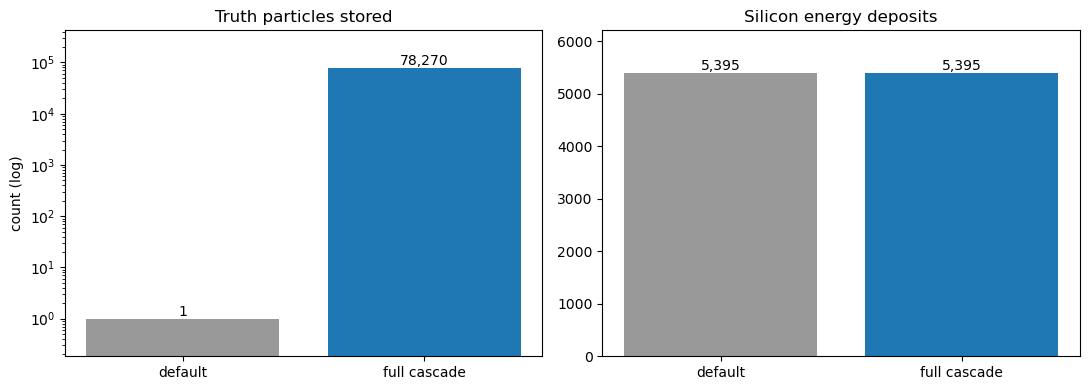

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt

def _find(name):
    for p in [os.path.join(os.environ.get("CALOMAPS_HOME", ""), "models", name),
              os.path.join("..", "models", name), os.path.join("models", name)]:
        if p and os.path.exists(p):
            return p
    return None

NPZ_FULL = _find("fullcascade_gamma50_1evt.npz")
NPZ_DEF  = _find("default_gamma50_1evt.npz")
if NPZ_FULL is None:
    raise FileNotFoundError("fullcascade_gamma50_1evt.npz not found — run analysis/extract_cascade.py first.")
d = np.load(NPZ_FULL, allow_pickle=True)

# default-config sample is optional (only for the comparison)
n_def_p = n_def_h = None
if NPZ_DEF:
    dd = np.load(NPZ_DEF, allow_pickle=True)
    n_def_p, n_def_h = len(dd["pdg"]), len(dd["hx"])

n_full_p, n_full_h = len(d["pdg"]), len(d["hx"])
print(f"MCParticles stored:   default = {n_def_p}   |   full cascade = {n_full_p:,}")
print(f"ECalBarrelHits:       default = {n_def_h}   |   full cascade = {n_full_h:,}")
print("(same random seed => identical hits; only the truth-particle list differs)")

if NPZ_DEF:
    fig, ax = plt.subplots(1, 2, figsize=(11, 4))
    for a, (lab, vals, title) in zip(ax, [
            ("MCParticles kept", [n_def_p, n_full_p], "Truth particles stored"),
            ("ECal hits",        [n_def_h, n_full_h], "Silicon energy deposits")]):
        bars = a.bar(["default", "full cascade"], vals, color=["#999999", "#1f77b4"])
        a.set_title(title); a.bar_label(bars, fmt="{:,.0f}")
        a.margins(y=0.15)
    ax[0].set_yscale("log"); ax[0].set_ylabel("count (log)")
    plt.tight_layout(); plt.show()

**Why the particle counts differ so wildly, yet the hits are identical.** Both runs use
the *same* primary photon and the *same* random seed, so Geant4 produces the *same* physical
shower and deposits the *same* energy in the *same* silicon cells — the hit count and total
deposit match exactly (right panel). What `keepAllParticles` / `userParticleHandler` change is
purely **bookkeeping**: whether the truth-particle records are *written out* or merged away.
The detector signal (the hits) never depended on storing the particle list. Keeping the full
cascade simply lets us *also* see the tens of thousands of particles that produced those hits
— which is what we need to eventually feed a pixel-level simulation.

In [2]:
# Pull the full-cascade arrays used by the rest of the notebook
pdg, mass, E = d["pdg"], d["mass"], d["E"]
px, py, pz = d["px"], d["py"], d["pz"]            # momentum at production (GeV)
pex, pey, pez = d["pex"], d["pey"], d["pez"]      # momentum at end of track (GeV)
vsx, vsy, vsz = d["vsx"], d["vsy"], d["vsz"]      # production vertex (mm)
vex, vey, vez = d["vex"], d["vey"], d["vez"]      # end vertex (mm)
hx, hy, hz, he = d["hx"], d["hy"], d["hz"], d["he"]  # hits (mm, GeV)

print(f"loaded: {NPZ_FULL}")
print(f"arrays: {list(d.keys())}")
print(f"\nN shower particles: {len(pdg):,}   N silicon hits: {len(hx):,}")
print(f"Total deposited E in Si: {he.sum():.3f} GeV  (sampling fraction ~{he.sum()/50:.2%})")
print(f"Primary (particle 0): pdg={pdg[0]}, E={E[0]:.1f} GeV, p=({px[0]:.2f},{py[0]:.1f},{pz[0]:.2f}) GeV")

loaded: /nashome/m/murtazas/CALOMAPS/models/fullcascade_gamma50_1evt.npz
arrays: ['pdg', 'mass', 'px', 'py', 'pz', 'E', 'pex', 'pey', 'pez', 'vsx', 'vsy', 'vsz', 'vex', 'vey', 'vez', 'pid', 'status', 'gstat', 'dbeg', 'dend', 'dau', 'hx', 'hy', 'hz', 'he', 'meta']

N shower particles: 78,270   N silicon hits: 5,395
Total deposited E in Si: 0.531 GeV  (sampling fraction ~1.06%)
Primary (particle 0): pdg=22, E=50.0 GeV, p=(0.00,50.0,0.00) GeV


## 3. Particle composition

An EM shower grows by two interleaved processes: **pair production** (γ → e⁺e⁻ in a nucleus's
field) and **bremsstrahlung** (e± radiating γ). They feed each other, so the cascade is
overwhelmingly electrons, positrons and photons.

**Why far more electrons than positrons?** Pair production makes e⁺ and e⁻ in equal numbers,
but electrons get three *extra* sources that create no positrons: **ionization / delta rays**
(any charged particle knocking atomic electrons loose), **Compton scattering**, and the
**photoelectric effect** (both eject atomic electrons). Meanwhile positrons are *removed* by
**annihilation** (e⁺ → γγ) at the end of their range. Net effect: e⁻ outnumber e⁺ by about an
order of magnitude here — a real, expected asymmetry, not a bug.

The handful of neutrons, protons and excited tungsten nuclei (PDG `100074xxxx`) come from
**photonuclear** interactions of shower photons with the W absorber.

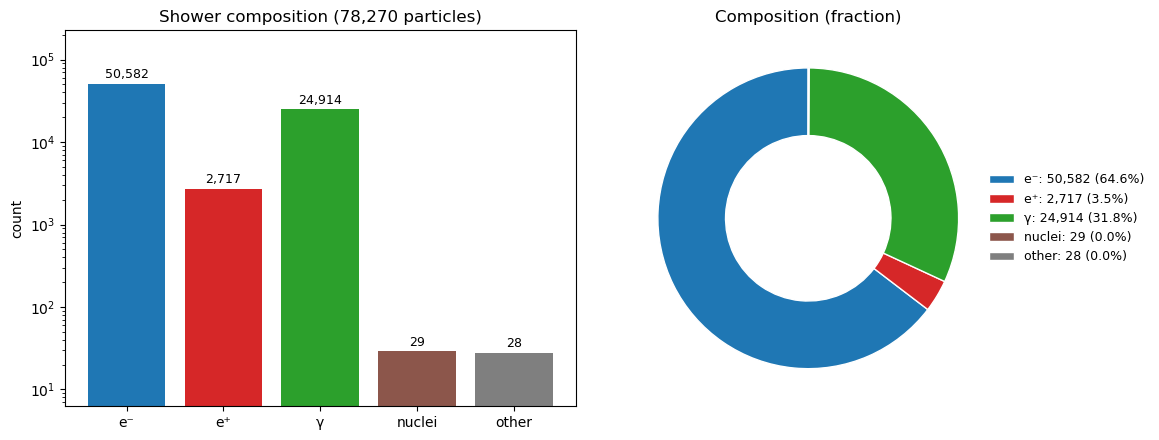

top PDG codes: [(11, 50582), (22, 24914), (-11, 2717), (2112, 24), (2212, 4), (1000741830, 4), (1000741820, 4), (1000741810, 4)]


In [3]:
uniq, counts = np.unique(pdg, return_counts=True)
order = np.argsort(-counts)

# Group: e-, e+, gamma, nuclei (|pdg|>1e9), other
groups = {"e⁻": 0, "e⁺": 0, "γ": 0, "nuclei": 0, "other": 0}
for p, c in zip(uniq, counts):
    if p == 11: groups["e⁻"] += c
    elif p == -11: groups["e⁺"] += c
    elif p == 22: groups["γ"] += c
    elif abs(p) > 1_000_000_000: groups["nuclei"] += c
    else: groups["other"] += c
g = {k: v for k, v in groups.items() if v}
cols = ["#1f77b4", "#d62728", "#2ca02c", "#8c564b", "#7f7f7f"][:len(g)]

fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
bars = ax[0].bar(g.keys(), g.values(), color=cols)
ax[0].set_yscale("log"); ax[0].set_ylabel("count")
ax[0].set_title(f"Shower composition ({len(pdg):,} particles)")
ax[0].bar_label(bars, fmt="{:,.0f}", padding=2, fontsize=9)
ax[0].margins(y=0.2)

# Pie: labels go in a legend (avoids overlap on the tiny nuclei/other slices);
# percentages are drawn only on slices large enough to read.
total = sum(g.values())
wedges, _ = ax[1].pie(list(g.values()), colors=cols, startangle=90,
                      wedgeprops=dict(width=0.45, edgecolor="w"))
ax[1].set_title("Composition (fraction)")
ax[1].legend(wedges, [f"{k}: {v:,} ({v/total:.1%})" for k, v in g.items()],
             loc="center left", bbox_to_anchor=(0.95, 0.5), frameon=False, fontsize=9)
plt.tight_layout(); plt.show()
print("top PDG codes:", [(int(uniq[i]), int(counts[i])) for i in order[:8]])

## 4. Energy spectrum

**Left — the spectrum itself.** Each shower generation roughly *halves* the energy while
*doubling* the particle count, so the number of secondaries climbs steeply toward low energy:
a near-power-law fall spanning many decades. Multiplication stops once particles drop below
the ~MeV scale (e± can no longer pair-produce or radiate efficiently), so the cascade "dies"
into a sea of soft e±/γ. The few entries far to the right are the *top* of the cascade: the
primary and its first-conversion e⁺e⁻, carrying tens of GeV.

**The three species have distinctly different shapes:**
- **γ (green)** reaches the **lowest energies** — down to ~1 keV here. Photons keep being made
  throughout the cascade (bremsstrahlung, atomic de-excitation) and, being massless, their
  *total* energy *is* their kinetic energy, so there is no floor. Below ~1 MeV they can no
  longer pair-produce, so they stop multiplying but linger as a soft sea until photoelectric
  absorption finally removes them. The 0.511 MeV spike (next paragraph) rides on top.
- **e⁻ (blue)** falls steeply and sits **above e⁺ at every energy** (the extra electron-only
  sources from §3). Crucially, both e± spectra **stop dead at 0.511 MeV**: a particle's *total*
  energy E = √(p²+m²) can never fall below its rest mass mₑc² = 0.511 MeV, so a stopped
  electron (KE → 0) piles up right at that edge. It is the *same* 0.511 MeV as the photon line —
  same mₑc², different reason (rest-mass floor vs annihilation photons).
- **e⁺ (red)** tracks e⁻ at high energy (pair production is symmetric) but is depleted toward
  the floor — stopped positrons **annihilate**, which is what feeds the photon line.

**The sharp photon spike at 0.511 MeV is the positron-annihilation line** — a real spectral
*line*, not a threshold. Every positron, once it slows to rest in the dense W/Si, annihilates
with an atomic electron (**e⁺e⁻ → 2γ**), emitting two back-to-back photons each carrying
exactly the electron rest energy, mₑc² = 511 keV. With thousands of positrons stopping in the
calorimeter these monoenergetic photons pile up: here **~20% of all photons** sit within a few
percent of 511 keV. (The dotted marker sits at mₑc² for exactly this reason.)

**Right — where the energy actually is.** The cumulative curve shows the central tension of
calorimetry: although almost all *particles* are soft, almost all the *energy* is carried by
the handful of *hard* particles near the top of the cascade. Yet the measurable **signal**
(the silicon hits) is made by the enormous number of soft particles ionizing the sensors — so
a good calorimeter has to faithfully collect charge from the soft sea, even though the energy
"lives" in a few hard tracks.

**Why nuclei are excluded from this plot.** The quantity plotted is *total* energy
E = √(p² + m²). For e±/γ the rest mass is negligible, so E is essentially the kinematic
(shower-relevant) energy. But a recoiling nucleus — e.g. a tungsten ion, m ≈ 173 GeV — is
nearly at rest with only keV–MeV of kinetic energy; its *total* energy is almost entirely rest
mass, which would plant spurious ~170-GeV entries far off the right edge and misrepresent the
shower.

> ⚠️ **A 50 GeV photon, yet "particles" at 173 GeV?** Not an energy-budget violation. That
> ~173 GeV is a tungsten nucleus's **rest mass** (E = mc², ~184 nucleons) — it was already
> sitting in the absorber before the event, *not* energy delivered by the photon. The photon
> only gives the nucleus a **≤ MeV recoil**; its 50 GeV is fully conserved, spent on the
> *kinetic* energies of the shower. The kinetic-energy plot below makes this obvious: the
> nuclei drop to keV–MeV, where they belong.

(The nuclei are also a negligible handful and don't drive the EM cascade.)

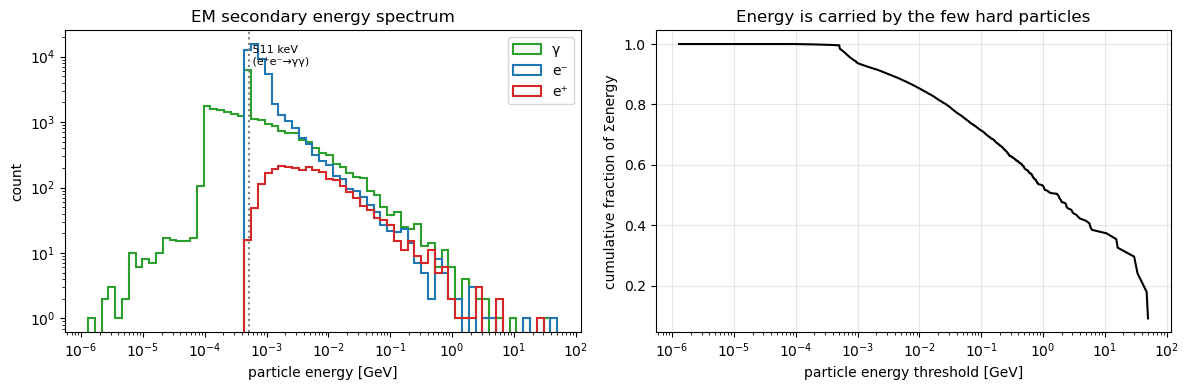

median EM particle energy: 0.66 MeV
# EM particles above 1 GeV: 43 (0.05%)


In [4]:
em = (pdg == 11) | (pdg == -11) | (pdg == 22)
Eem = E[em]
Eem = Eem[Eem > 0]
assert Eem.size, "no EM (e/gamma) particles with E>0 in this event — energy-spectrum plot needs them"

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
bins = np.logspace(np.log10(max(Eem.min(), 1e-6)), np.log10(Eem.max()), 70)   # down to ~keV: show the full soft sea
for sel, lab, col in [(pdg == 22, "γ", "#2ca02c"), (pdg == 11, "e⁻", "#1f77b4"), (pdg == -11, "e⁺", "#d62728")]:
    es = E[sel]; es = es[es > 0]
    ax[0].hist(es, bins=bins, histtype="step", label=lab, color=col, lw=1.5)
ax[0].set_xscale("log"); ax[0].set_yscale("log")
ax[0].set_xlabel("particle energy [GeV]"); ax[0].set_ylabel("count")
ax[0].set_title("EM secondary energy spectrum"); ax[0].legend()
ax[0].axvline(0.000511, ls=":", color="grey"); ax[0].text(0.000511, ax[0].get_ylim()[1]*0.3, " 511 keV\n (e⁺e⁻→γγ)", fontsize=8)

es = np.sort(Eem)[::-1]
ax[1].plot(es, np.cumsum(es)/es.sum(), color="black")
ax[1].set_xscale("log"); ax[1].set_xlabel("particle energy threshold [GeV]")
ax[1].set_ylabel("cumulative fraction of Σenergy"); ax[1].set_title("Energy is carried by the few hard particles")
ax[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()
print(f"median EM particle energy: {np.median(Eem)*1000:.2f} MeV")
print(f"# EM particles above 1 GeV: {(Eem>1).sum():,} ({(Eem>1).mean():.2%})")

### Kinetic energy — bringing the nuclei (and hadrons) back

The spectrum above used *total* energy E = √(p²+m²), which is why nuclei had to be dropped
(their E is almost all rest mass). The physically meaningful quantity for a slow, massive
recoil is the **kinetic energy** T = E − m. Plotted in T, every species sits at its true
kinematic energy — so we can show the *whole* particle inventory on one axis, including the
photonuclear neutrons, protons and tungsten nuclei, which land at keV–MeV (not ~170 GeV).

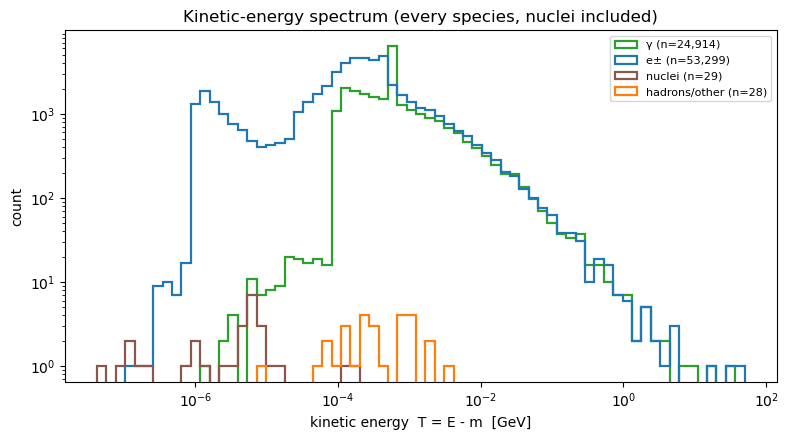

nuclei: n=29, kinetic energy 0.0 eV - 0.2 MeV
  ...their TOTAL energy E would be ~173 GeV (essentially all rest mass)


In [5]:
T = E - mass   # kinetic energy (GeV)
nuc = np.abs(pdg) > 1_000_000_000
groups = [(pdg == 22, "γ", "#2ca02c"), ((pdg == 11) | (pdg == -11), "e±", "#1f77b4"),
          (nuc, "nuclei", "#8c564b"),
          (~nuc & (pdg != 22) & (pdg != 11) & (pdg != -11), "hadrons/other", "#ff7f0e")]
Tpos = T[T > 0]
bins = np.logspace(np.log10(max(Tpos.min(), 1e-9)), np.log10(Tpos.max()), 70)

fig, ax = plt.subplots(figsize=(8, 4.5))
for sel, lab, col in groups:
    t = T[sel & (T > 0)]
    if t.size:
        ax.hist(t, bins=bins, histtype="step", lw=1.6, color=col, label=f"{lab} (n={int(sel.sum()):,})")
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("kinetic energy  T = E - m  [GeV]"); ax.set_ylabel("count")
ax.set_title("Kinetic-energy spectrum (every species, nuclei included)"); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()
if nuc.any():
    print(f"nuclei: n={int(nuc.sum())}, kinetic energy {T[nuc].min()*1e6:.1f} eV - {T[nuc].max()*1e3:.1f} MeV")
    print(f"  ...their TOTAL energy E would be ~{mass[nuc].max():.0f} GeV (essentially all rest mass)")

## 5. Longitudinal & radial shower development

The beam travels +y; the ECal front face is at r = 1264 mm. The calorimeter is a stack of
**tungsten-absorber / silicon-sensor** layers (from `my_custom_ecal.xml`): 20 layers of
2.5 mm W + 0.32 mm Si, then 10 layers of 5 mm W + 0.32 mm Si. The shaded **gray bands** in the
first two panels mark the tungsten slabs.

**Left — where particles are born (by species).** The production-vertex profile shows a *comb*
locked to the layers: far more secondaries are created **inside the tungsten** than in the thin
Si/air gaps. Tungsten is dense and high-Z, with a radiation length of only ~3.5 mm versus
~94 mm for silicon — so pair production and bremsstrahlung (which *make* the new particles)
happen overwhelmingly in the absorber. That is the origin of the step-between-bins behaviour:
peaks sit in the gray W bands, dips in the gaps.

**Middle — where energy is measured.** This is built from the **hits**, and hits exist *only in
the silicon* — the tungsten is a passive absorber with no readout. So the deposited-energy
points fall in the thin gaps *between* the W bands (the Si layers), never inside them; the
y-axis here samples only the silicon. As a geometry cross-check, the layer model puts the
deepest Si layer at y ≈ 1400.7 mm, exactly where the last hits are. This panel is not split by
species because a hit does not record which particle deposited it — that link is the
`CaloHitContribution` truth of experiment "B".

**Right — radial (lateral) profile.** Perpendicular to the beam, energy lands in a tight core
that falls off with transverse radius √(x²+z²) — the lateral spread set by multiple scattering
and the EM Molière radius. The printout reports the 90% / 95% energy-containment radii.

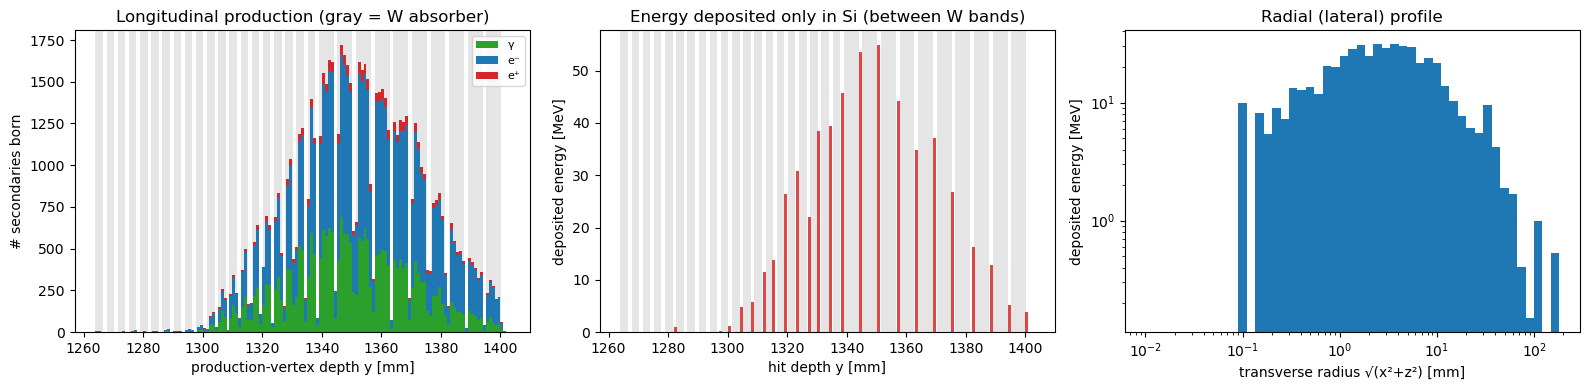

Si-layer model: 30 layers, first y=1266.9 mm, last y=1400.7 mm (deepest hit at y=1400.8 mm — matches)
90% of deposited energy within transverse radius 12.5 mm
95% of deposited energy within transverse radius 23.7 mm


In [6]:
# --- W/Si layer model (geometry/my_custom_ecal.xml; ECal front rmin = 1264 mm) ---
rmin = 1264.0
w_bands, si_pos, yy = [], [], rmin
for nrep, wthick in [(20, 2.5), (10, 5.0)]:
    pitch = wthick + 0.25 + 0.32 + 0.05 + 0.30 + 0.33    # W + air + Si + Cu + Kapton + air (mm)
    for _ in range(nrep):
        w_bands.append((yy, yy + wthick))                # tungsten slab
        si_pos.append(yy + wthick + 0.25 + 0.16)         # silicon-layer centre
        yy += pitch
def draw_W(a):
    for lo, hi in w_bands:
        a.axvspan(lo, hi, color="0.6", alpha=0.25, lw=0)

species = [(pdg == 22, "γ", "#2ca02c"), (pdg == 11, "e⁻", "#1f77b4"), (pdg == -11, "e⁺", "#d62728")]
dbins = np.linspace(rmin, 1403, 140)
fig, ax = plt.subplots(1, 3, figsize=(16, 4))

# (a) production by species, stacked, with the W bands behind
draw_W(ax[0])
inwin = (vsy > rmin) & (vsy < 1403)
ax[0].hist([vsy[m & inwin] for m, _, _ in species], bins=dbins, stacked=True,
           label=[lab for _, lab, _ in species], color=[c for _, _, c in species])
ax[0].set_xlabel("production-vertex depth y [mm]"); ax[0].set_ylabel("# secondaries born")
ax[0].set_title("Longitudinal production (gray = W absorber)"); ax[0].legend(fontsize=8)

# (b) energy deposition (hits) -- only in Si, i.e. in the gaps between the W bands
draw_W(ax[1])
ax[1].hist(hy, bins=dbins, weights=he * 1000, color="#d62728", alpha=0.85)
ax[1].set_xlabel("hit depth y [mm]"); ax[1].set_ylabel("deposited energy [MeV]")
ax[1].set_title("Energy deposited only in Si (between W bands)")

# (c) radial / lateral profile
rho = np.hypot(hx, hz)   # transverse distance from the +y beam axis
rb = np.logspace(np.log10(max(rho[rho > 0].min(), 1e-2)), np.log10(rho.max() + 1), 50)
ax[2].hist(rho, bins=rb, weights=he * 1000, color="#1f77b4")
ax[2].set_xscale("log"); ax[2].set_yscale("log")
ax[2].set_xlabel("transverse radius √(x²+z²) [mm]"); ax[2].set_ylabel("deposited energy [MeV]")
ax[2].set_title("Radial (lateral) profile")
plt.tight_layout(); plt.show()

print(f"Si-layer model: {len(si_pos)} layers, first y={si_pos[0]:.1f} mm, last y={si_pos[-1]:.1f} mm "
      f"(deepest hit at y={hy.max():.1f} mm — matches)")
o = np.argsort(rho); cumE = np.cumsum(he[o]) / he.sum(); rsort = np.sort(rho)
for frac in (0.90, 0.95):
    print(f"{frac:.0%} of deposited energy within transverse radius {rsort[np.searchsorted(cumE, frac)]:.1f} mm")

## 6. Shower shape — transverse spread and 3D view

**These plots use the silicon *hits* (energy deposits), not the truth particles.** They show
where energy actually lands in the sensors — the *measurable* shower image — as opposed to the
particle-level views in §3–§5 (left) and §7, which come from the MCParticle truth. (So there
is no per-particle-type breakdown here: a hit only knows its position and deposited energy, not
which particle made it — that link is the `CaloHitContribution` truth of experiment "B".)

Transverse coordinates are x and z (the beam is +y); the shower is narrow near the front and
spreads with depth. Hit positions are colored by deposited energy.

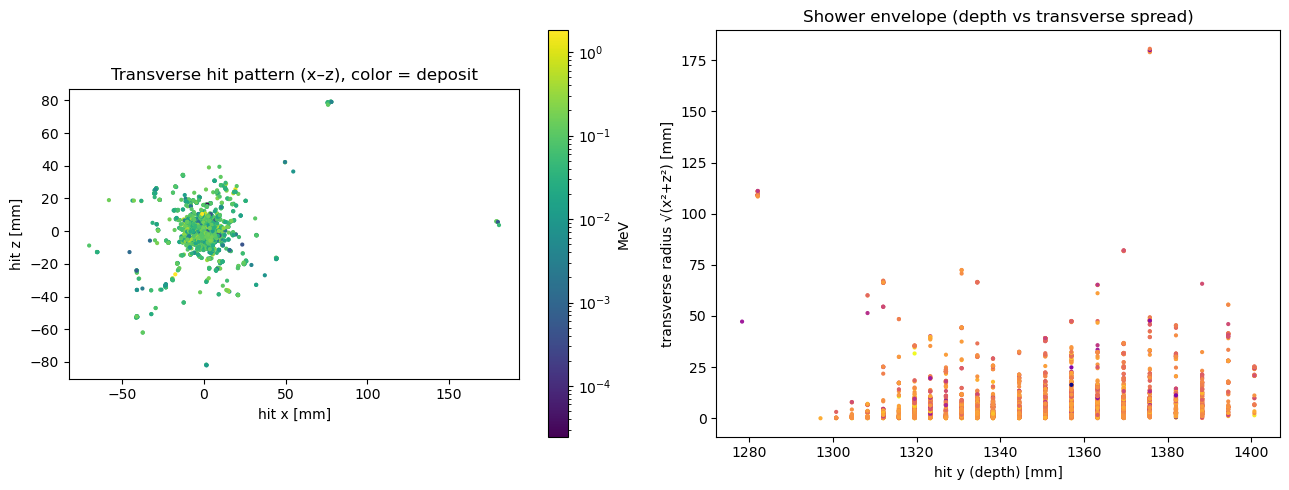

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(13, 5))
sc = ax[0].scatter(hx, hz, c=he*1000, s=4, cmap="viridis", norm=plt.matplotlib.colors.LogNorm())
ax[0].set_xlabel("hit x [mm]"); ax[0].set_ylabel("hit z [mm]"); ax[0].set_aspect("equal")
ax[0].set_title("Transverse hit pattern (x–z), color = deposit"); plt.colorbar(sc, ax=ax[0], label="MeV")

rt = np.hypot(hx, hz)
ax[1].scatter(hy, rt, c=he*1000, s=4, cmap="plasma", norm=plt.matplotlib.colors.LogNorm())
ax[1].set_xlabel("hit y (depth) [mm]"); ax[1].set_ylabel("transverse radius √(x²+z²) [mm]")
ax[1].set_title("Shower envelope (depth vs transverse spread)")
plt.tight_layout(); plt.show()

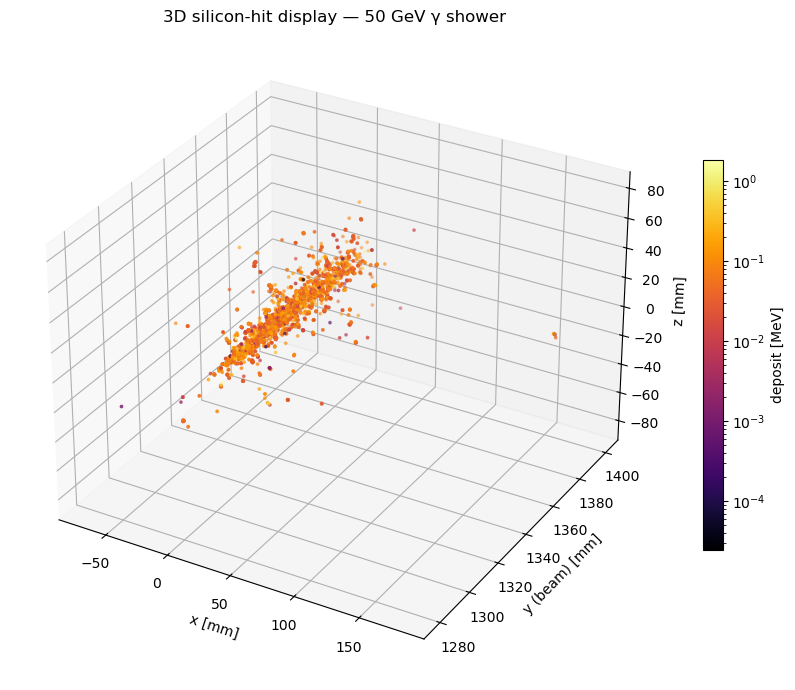

In [8]:
from mpl_toolkits.mplot3d import Axes3D  # noqa
fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection="3d")
sub = slice(None) if len(hx) < 20000 else np.random.default_rng(0).choice(len(hx), 20000, replace=False)
p = ax.scatter(hx[sub], hy[sub], hz[sub], c=he[sub]*1000, s=3, cmap="inferno",
               norm=plt.matplotlib.colors.LogNorm())
ax.set_xlabel("x [mm]"); ax.set_ylabel("y (beam) [mm]"); ax.set_zlabel("z [mm]")
ax.set_title("3D silicon-hit display — 50 GeV γ shower")
fig.colorbar(p, label="deposit [MeV]", shrink=0.6)
plt.tight_layout(); plt.show()

## 7. Momentum directions

A particle's opening angle is a competition between **relativistic beaming** and **multiple
scattering**. Bremsstrahlung and pair production emit their products within a characteristic
angle ~ mₑc²/E of the parent's direction (higher energy ⇒ tighter cone), so freshly-made *hard*
particles are sharply forward. But once a particle slows to the ~MeV scale, multiple Coulomb
scattering randomises its direction — and since the cascade is overwhelmingly soft (§4), the
*bulk* of particles end up nearly isotropic. The three panels disentangle this.

**Left — opening angle, by species.** Compare each curve to the dashed reference an *isotropic*
3-D distribution would give (dN/dθ ∝ sinθ, peaking at θ = 90°). The three species look
strikingly different, and the difference is all **production mechanism**:
- **e⁺ (red) are the most forward** — median ≈ 17°, ~35% within 10° of the beam. Positrons are
  made *only* by pair production, which is forward-beamed; there is no positron analogue of
  knock-out electrons, so they stay close to their forward origin.
- **e⁻ (blue) are the widest** — median ≈ 73°, peaking near 90° and with ~36% going *backward*.
  Electrons get the extra wide-angle sources from §3 — **delta rays** kicked sideways by
  ionisation, plus Compton and photoelectric electrons — and the huge soft-electron sea is
  fully multiple-scattered, so it traces almost exactly the isotropic sinθ shape.
- **γ (green) sit in between** — median ≈ 49°, with a sharp forward spike. Bremsstrahlung
  photons are beamed forward, while soft photons and the **isotropic 511 keV annihilation
  photons** (emitted every which way by stopped positrons) fill in all the other angles.

**Middle — azimuthal symmetry.** The azimuth φ in the transverse x–z plane is **flat**, as it
must be: beam on-axis, no magnetic field, so no preferred transverse direction. A non-flat φ
would flag a geometry or bookkeeping bug — a cheap but genuine validation.

**Right — collimation vs energy.** The cleanest statement of the beaming-vs-scattering
competition: the median opening angle plunges from ~70° for the soft sea (E < 10 MeV) to
**0.08°** for E > 1 GeV (essentially every hard track is within 10° of the beam). A particle's
angle is set almost entirely by its energy. *This per-track opening angle — direction as a
function of how hard the particle is — is exactly the input a pixel-level simulation needs.*

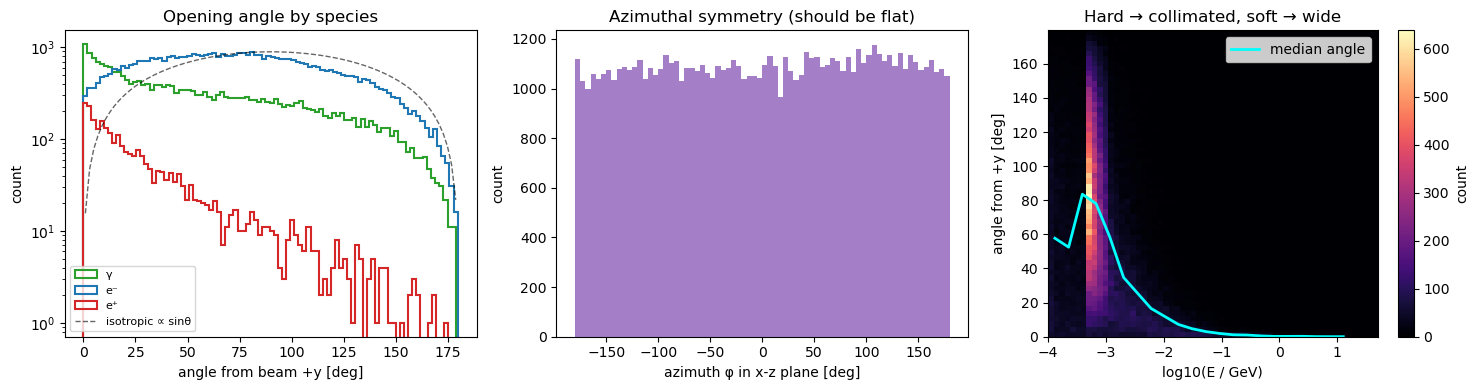

median opening angle: all = 64.7°, E>1 GeV = 0.08°, E<10 MeV = 67.5°


In [9]:
pmag = np.sqrt(px**2 + py**2 + pz**2)
good = (pmag > 0) & em
theta = np.degrees(np.arccos(np.clip(py[good] / pmag[good], -1, 1)))   # angle from +y beam
phi   = np.degrees(np.arctan2(pz[good], px[good]))                     # azimuth in the x-z plane
Eg, gpdg = E[good], pdg[good]

fig, ax = plt.subplots(1, 3, figsize=(15, 4))
# (a) opening angle, split by species, against an isotropic (sin theta) reference
for sel, lab, col in [(gpdg==22,"γ","#2ca02c"), (gpdg==11,"e⁻","#1f77b4"), (gpdg==-11,"e⁺","#d62728")]:
    ax[0].hist(theta[sel], bins=90, histtype="step", lw=1.5, color=col, label=lab)
_cnt, _ed = np.histogram(theta[gpdg==11], bins=90); _tc = 0.5*(_ed[:-1]+_ed[1:])
_ref = np.sin(np.radians(_tc)); _ref *= _cnt.max()/_ref.max()
ax[0].plot(_tc, _ref, "k--", lw=1, alpha=0.6, label="isotropic ∝ sinθ")
ax[0].set_yscale("log"); ax[0].set_xlabel("angle from beam +y [deg]"); ax[0].set_ylabel("count")
ax[0].set_title("Opening angle by species"); ax[0].legend(fontsize=8)
# (b) azimuthal symmetry (should be flat)
ax[1].hist(phi, bins=72, color="#9467bd", alpha=0.85)
ax[1].set_xlabel("azimuth φ in x-z plane [deg]"); ax[1].set_ylabel("count"); ax[1].set_ylim(bottom=0)
ax[1].set_title("Azimuthal symmetry (should be flat)")
# (c) collimation vs energy, with a median profile
le = np.log10(np.clip(Eg, 1e-4, None))
h = ax[2].hist2d(le, theta, bins=[60, 60], cmap="magma")
xb = np.linspace(le.min(), le.max(), 25); xc = 0.5*(xb[:-1]+xb[1:])
med = [np.median(theta[(le>=lo)&(le<hi)]) if ((le>=lo)&(le<hi)).any() else np.nan for lo, hi in zip(xb[:-1], xb[1:])]
ax[2].plot(xc, med, color="cyan", lw=2, label="median angle")
ax[2].set_xlabel("log10(E / GeV)"); ax[2].set_ylabel("angle from +y [deg]")
ax[2].set_title("Hard → collimated, soft → wide"); ax[2].legend()
plt.colorbar(h[3], ax=ax[2], label="count")
plt.tight_layout(); plt.show()
print(f"median opening angle: all = {np.median(theta):.1f}°, "
      f"E>1 GeV = {np.median(theta[Eg>1]):.2f}°, E<10 MeV = {np.median(theta[Eg<0.01]):.1f}°")

## 8. Validating the truth — are the 4-vectors and vertices self-consistent?

**First, a key conceptual point.** One might expect a particle to travel in a straight line
from birth to death at constant energy — but that is not what the two vertices describe. The
*production* and *end* vertex bracket a particle's **entire trajectory**, not one straight
step. Between them the particle traverses its full range: a charged particle continuously
**loses energy** (ionisation + bremsstrahlung) *and* **changes direction** (multiple Coulomb
scattering) the whole way, while a neutral photon travels straight at constant energy *between*
interactions but is kinked by any Compton scatter. So the start→end segment is generally
neither straight nor energy-conserving, and the deviations below are physics, not artefacts.
Four cross-checks:

1. **Masses** match the PDG values (e± = 0.511 MeV, γ = 0).
2. **Energy conservation** at the first vertex — the primary photon's energy is shared by the
   e⁺e⁻ it pair-produces.
3. **Displacement vs momentum** — the start→end vector vs the *production* momentum. Photons
   are mostly perfectly aligned (straight); the tails are particles that got deflected.
4. **Energy loss** — the end momentum never exceeds the start. In fact almost *every* particle
   ends at rest (p_end ≈ 0): the soft cascade fully thermalises.

MASS CHECK [GeV]:
  e-: 0.000511   e+: 0.000511   gamma: 0.000000   (PDG: 0.000511, 0.000511, 0)

PRIMARY: pdg=22, E=50.00 GeV, converts at (0.0,1295.3,0.0) mm
products born there: 2 particle(s), pdg=[-11, 11], E = 47.59 + 2.41 = 50.00 GeV  (= primary 50.00 GeV)
  isolation check - particles within 1 µm / 10 µm / 100 µm of the conversion point: 2 / 2 / 2


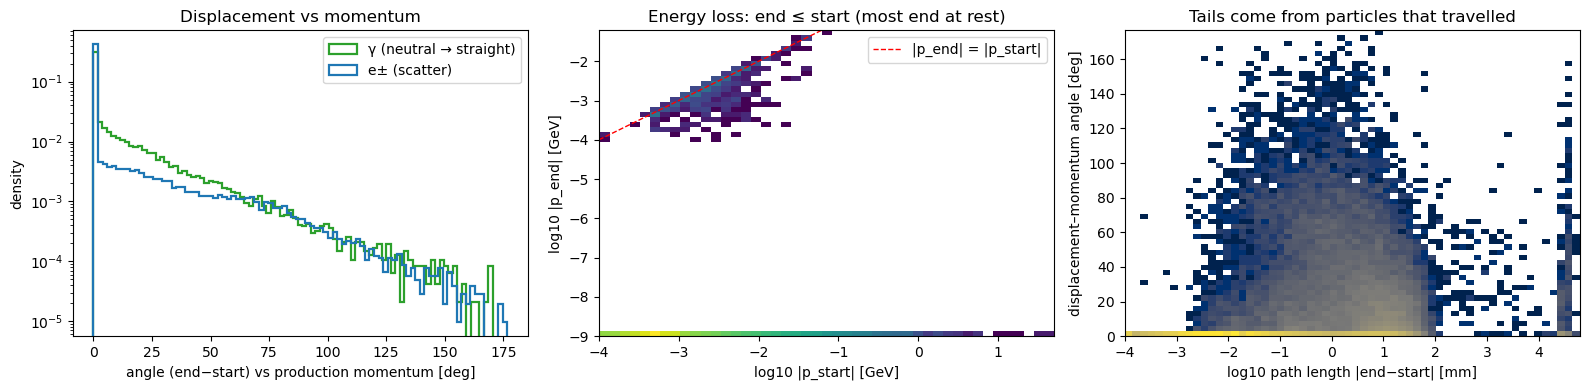

fraction with |p_end| <= |p_start|: 100.0%;  fraction ending at rest (p_end<1e-4 GeV): 99.3%
photons ending at p≈0 (converted/absorbed): 24,356 / 24,914


In [10]:
# 1) masses vs PDG
mm = lambda s: float(mass[s].mean()) if s.any() else float("nan")
print("MASS CHECK [GeV]:")
print(f"  e-: {mm(pdg==11):.6f}   e+: {mm(pdg==-11):.6f}   gamma: {mm(pdg==22):.6f}   (PDG: 0.000511, 0.000511, 0)")

# 2) first-vertex energy conservation. Pair-production products share the photon's conversion
#    point *exactly* (same Geant4 step point), so a 1 µm tolerance isolates them from the
#    downstream secondaries (born further along, once the e± have travelled a finite distance).
def _within(tol):
    return (np.abs(vsx-vex[0]) < tol) & (np.abs(vsy-vey[0]) < tol) & (np.abs(vsz-vez[0]) < tol)
conv = np.where(_within(1e-3))[0]
conv = conv[conv != 0]   # exclude the primary itself (it ends far from where it started)
print(f"\nPRIMARY: pdg={pdg[0]}, E={E[0]:.2f} GeV, converts at ({vex[0]:.1f},{vey[0]:.1f},{vez[0]:.1f}) mm")
print(f"products born there: {len(conv)} particle(s), pdg={sorted(set(int(pdg[i]) for i in conv))}, "
      f"E = {' + '.join(f'{E[i]:.2f}' for i in conv)} = {E[conv].sum():.2f} GeV  (= primary {E[0]:.2f} GeV)")
print(f"  isolation check - particles within 1 µm / 10 µm / 100 µm of the conversion point: "
      f"{int(_within(1e-3).sum())} / {int(_within(1e-2).sum())} / {int(_within(1e-1).sum())}")

# 3) displacement vs momentum, and 4) energy loss
disp = np.stack([vex-vsx, vey-vsy, vez-vsz], axis=1); dlen = np.linalg.norm(disp, axis=1)
pvec = np.stack([px, py, pz], axis=1);                pm   = np.linalg.norm(pvec, axis=1)
ok = (dlen > 1e-6) & (pm > 1e-9)
ang = np.degrees(np.arccos(np.clip(np.einsum("ij,ij->i", disp[ok], pvec[ok]) / (dlen[ok]*pm[ok]), -1, 1)))
okp = pdg[ok]

fig, ax = plt.subplots(1, 3, figsize=(16, 4))
# (a) displacement vs PRODUCTION momentum, by species
for sel, lab, col in [(okp==22,"γ (neutral → straight)","#2ca02c"), ((okp==11)|(okp==-11),"e± (scatter)","#1f77b4")]:
    if sel.any():
        ax[0].hist(ang[sel], bins=90, histtype="step", lw=1.6, color=col, label=lab, density=True)
ax[0].set_yscale("log"); ax[0].set_xlabel("angle (end−start) vs production momentum [deg]")
ax[0].set_ylabel("density"); ax[0].set_title("Displacement vs momentum"); ax[0].legend()

# (b) energy loss: end vs start momentum -- nearly everything ends at rest
pend = np.sqrt(pex**2 + pey**2 + pez**2); s = pm > 0
ax[1].hist2d(np.log10(np.clip(pm[s],1e-6,None)), np.log10(np.clip(pend[s],1e-9,None)),
             bins=[60,60], cmap="viridis", norm=plt.matplotlib.colors.LogNorm())
lim = [-4, np.log10(pm.max())]
ax[1].plot(lim, lim, "r--", lw=1, label="|p_end| = |p_start|")
ax[1].set_xlim(lim); ax[1].set_ylim(bottom=-9)
ax[1].set_xlabel("log10 |p_start| [GeV]"); ax[1].set_ylabel("log10 |p_end| [GeV]")
ax[1].set_title("Energy loss: end ≤ start (most end at rest)"); ax[1].legend()
ax[1].annotate("bottom row = stopped (p_end ≈ 0)", xy=(0.5, 0.03), xycoords="axes fraction",
               ha="center", fontsize=7, color="white")

# (c) WHY the tails -- the deflected particles are the ones that TRAVELLED far
ax[2].hist2d(np.log10(np.clip(dlen[ok], 1e-4, None)), ang, bins=[60, 60],
             cmap="cividis", norm=plt.matplotlib.colors.LogNorm())
ax[2].set_xlabel("log10 path length |end−start| [mm]"); ax[2].set_ylabel("displacement–momentum angle [deg]")
ax[2].set_title("Tails come from particles that travelled")
plt.tight_layout(); plt.show()
print(f"fraction with |p_end| <= |p_start|: {(pend <= pm + 1e-6).mean():.1%};  "
      f"fraction ending at rest (p_end<1e-4 GeV): {(pend < 1e-4).mean():.1%}")
print(f"photons ending at p≈0 (converted/absorbed): {int(((pdg==22)&(pend<1e-4)).sum()):,} / {int((pdg==22).sum()):,}")

**Reading the panels.** *Left:* photons (green) pile up at angle ≈ 0 — straight until a
discrete interaction — while the electron distribution has a long tail to large angles.
*Middle:* the dense **bottom row** is the ~99% of tracks that end at rest (p_end ≈ 0); the
cascade fully thermalises, so essentially everything loses ~100% of its momentum and "momentum
change" *cannot by itself* explain the angular tails. The red diagonal is the |p_end| = |p_start|
ceiling, which nothing crosses. *Right:* here the dense **bottom row** is the majority that go
essentially straight (displacement angle ≈ 0) — they stop before travelling far, or are neutral
photons. The angle only grows with **path length**: large-angle electrons travelled ~90× farther
than the straight ones (more distance ⇒ more accumulated multiple scattering), and large-angle
photons ~3× farther (they Compton-scattered, then continued). So the tails *are* the "affected"
particles — picked out by distance travelled, not by momentum lost.

## 9. Re-creating the shower — the cascade tree

Using the parent→daughter links (extracted from the EDM4hep `daughters` relation) we can draw
the actual **cascade tree**, not a set of disconnected tracks. Starting from the primary photon
we follow its hardest descendants, so every drawn track's parent is also drawn: the segments
**branch at the vertices** where new particles are created, and the electron → photon →
electron alternation of an electromagnetic shower becomes visible. Each segment runs from a
particle's production vertex to its end point, coloured by species; black dots mark the
production vertices (where one track spawns the next). We keep the hardest ~150 *connected*
e±/γ — the visible skeleton, with the soft sea omitted — and clip the incoming photon to the
ECal front (y = 1264 mm). The left panel (depth vs transverse) is usually the easiest to read;
the right is the same tree in 3D.

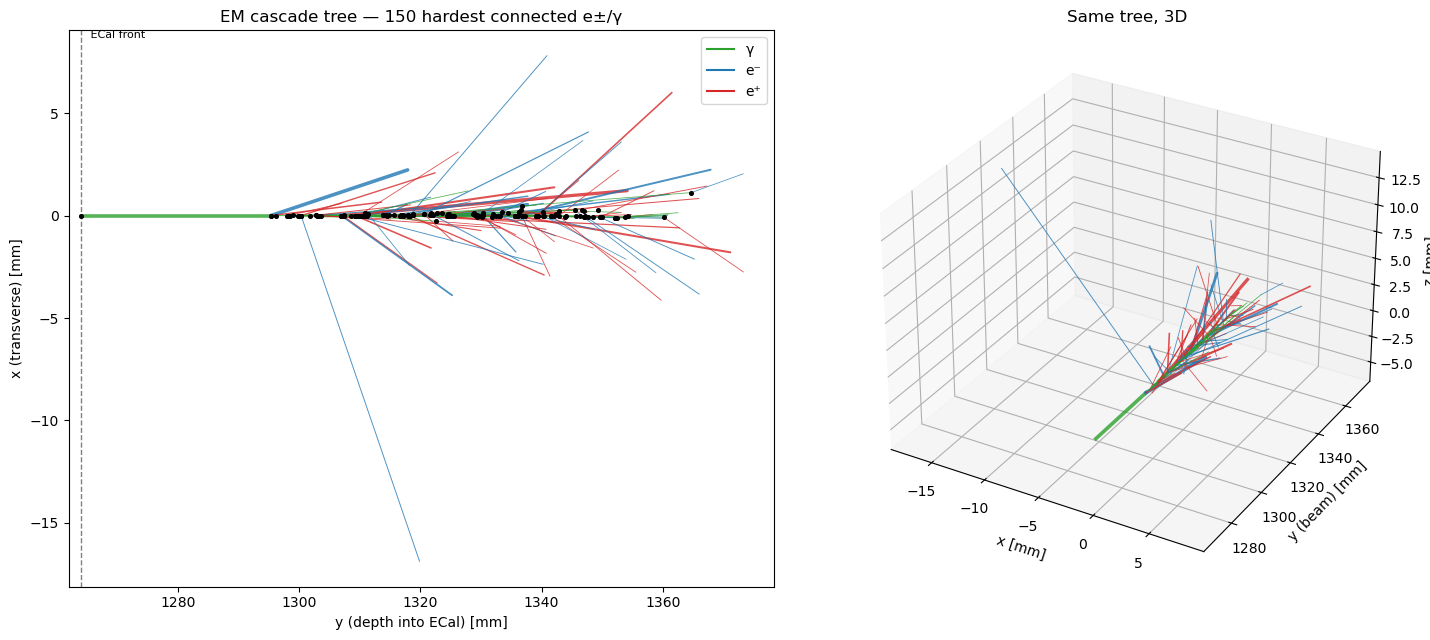

tree: 150 connected nodes — 76 e± + 74 γ; root = primary photon (50 GeV)
branching example — the primary's daughters: [(11, 47.59), (-11, 2.41)] GeV


In [11]:
import heapq
from mpl_toolkits.mplot3d import Axes3D  # noqa
dbeg, dend, dau = d["dbeg"], d["dend"], d["dau"]
children = lambda i: [int(c) for c in dau[dbeg[i]:dend[i]]]

# Grow a CONNECTED tree from the primary (index 0): repeatedly expand into the highest-energy
# reachable e±/γ daughter until N nodes. Every kept node's parent is also kept, so the drawn
# segments truly branch into one another instead of floating.
N = 150
keep, seen, heap = [], set(), [(-float(E[0]), 0)]
while heap and len(keep) < N:
    negE, i = heapq.heappop(heap)
    if i in seen:
        continue
    seen.add(i); keep.append(i)
    for c in children(i):
        if c not in seen and int(pdg[c]) in (22, 11, -11):
            heapq.heappush(heap, (-float(E[c]), c))

cmap = {22: "#2ca02c", 11: "#1f77b4", -11: "#d62728"}; pcol = lambda p: cmap[int(p)]
lw = lambda e: 0.4 + 1.3*np.log10(max(e, 1e-3) + 1)
cy = lambda v: max(float(v), 1264.0)   # clip the incoming primary photon to the ECal front
from matplotlib.lines import Line2D
legend = [Line2D([0],[0],color=c,label=l) for l,c in [("γ","#2ca02c"),("e⁻","#1f77b4"),("e⁺","#d62728")]]

fig = plt.figure(figsize=(15, 6.5))
# --- left: 2D projection (depth vs transverse) -- easiest to read ---
ax2 = fig.add_subplot(1, 2, 1)
for i in keep:
    ax2.plot([cy(vsy[i]), vey[i]], [vsx[i], vex[i]], color=pcol(pdg[i]), lw=lw(E[i]), alpha=0.8, solid_capstyle="round")
ax2.scatter([cy(vsy[i]) for i in keep], [vsx[i] for i in keep], s=7, color="k", zorder=3)
ax2.axvline(1264, ls="--", color="grey", lw=1); ax2.text(1265, ax2.get_ylim()[1], " ECal front", fontsize=8, va="top")
ax2.set_xlim(1262, max(vey[i] for i in keep) + 5)
ax2.set_xlabel("y (depth into ECal) [mm]"); ax2.set_ylabel("x (transverse) [mm]")
ax2.set_title(f"EM cascade tree — {len(keep)} hardest connected e±/γ"); ax2.legend(handles=legend, loc="upper right")

# --- right: same tree in 3D ---
ax = fig.add_subplot(1, 2, 2, projection="3d")
for i in keep:
    ax.plot([vsx[i],vex[i]], [cy(vsy[i]),vey[i]], [vsz[i],vez[i]], color=pcol(pdg[i]), lw=lw(E[i]), alpha=0.8)
xs = [c for i in keep for c in (vsx[i],vex[i])]; zs = [c for i in keep for c in (vsz[i],vez[i])]
ax.set_xlim(min(xs)-2, max(xs)+2); ax.set_ylim(1262, max(vey[i] for i in keep)+5); ax.set_zlim(min(zs)-2, max(zs)+2)
ax.set_xlabel("x [mm]"); ax.set_ylabel("y (beam) [mm]"); ax.set_zlabel("z [mm]"); ax.set_title("Same tree, 3D")
plt.tight_layout(); plt.show()

n_g = sum(1 for i in keep if pdg[i] == 22); n_em = len(keep) - n_g
print(f"tree: {len(keep)} connected nodes — {n_em} e± + {n_g} γ; root = primary photon ({E[0]:.0f} GeV)")
print(f"branching example — the primary's daughters: {[(int(pdg[c]), round(float(E[c]),2)) for c in children(0)]} GeV")

## Summary & next steps

- We can extract the **complete shower cascade** (tens of thousands of particles for a
  50 GeV γ): every secondary's PDG, 4-vector and production/end vertex — vs just the
  primary by default (see the §2 comparison).
- Physics checks out: pair-conversion of the primary, brem/pair cascade, a per-cent-level
  W/Si sampling fraction, forward-peaked but spreading secondaries.
- The truth is **self-consistent** (§8: masses, first-vertex energy conservation,
  displacement∥momentum, end-momentum ≤ start) and can be **redrawn as the actual cascade**
  (§9) — which is what makes it trustworthy input for a downstream pixel simulation.

**Toward PIXELAV:** PIXELAV needs, per charged track crossing a sensor, the local
**entry/exit points, direction cosines, and momentum**. That is *per-sensor step-level*
information (experiment "B") — the EDM4hep `CaloHitContribution` records on each
`SimCalorimeterHit` (per-step `PDG`, `energy`, `stepPosition`, + a link back to the
`MCParticle`) are the natural source, and are not yet pulled into the `.npz`. See
[`analysis/pixelav_converter.py`](../analysis/pixelav_converter.py) (scaffold).